In [1]:
import os

import pandas as pd
import numpy as np
import itertools
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.transforms import ScaledTranslation
from matplotlib.lines import Line2D

import loading as ld
import processing as prc
import visualization as viz

path_to_images = '/Users/Guille/Desktop/india_power/images'
path_to_output = '/Users/Guille/Desktop/india_power/output_csvs'
path_to_csvs = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'
path_to_input = '/Users/Guille/Desktop/india_power/input_data/'

In [2]:
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
load_zones_  = pd.read_csv(path_to_input + r"/load_zones.csv").drop(columns = ['state', 'rps_zone'])

In [3]:
scen_group = 'additional_1'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = ld._load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = ld._load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = prc._group_capacity_by_technology(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = prc._group_dispatch_by_technology(df_1_['dispatch'], tech_labels_)

# Save processed results in CSV files
prc._save_technology_capacity_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_capacity.csv')

prc._save_technology_capacity_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_dispatch.csv')

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(df_2_['scen_labels'])
cost_, demand_ = ld._load_cost(df_2_['scen_labels'])
clean_ = ld._load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = prc._group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = prc._group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(df_2_, path_to_output, file_name = f'{scen_group}' + '-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath

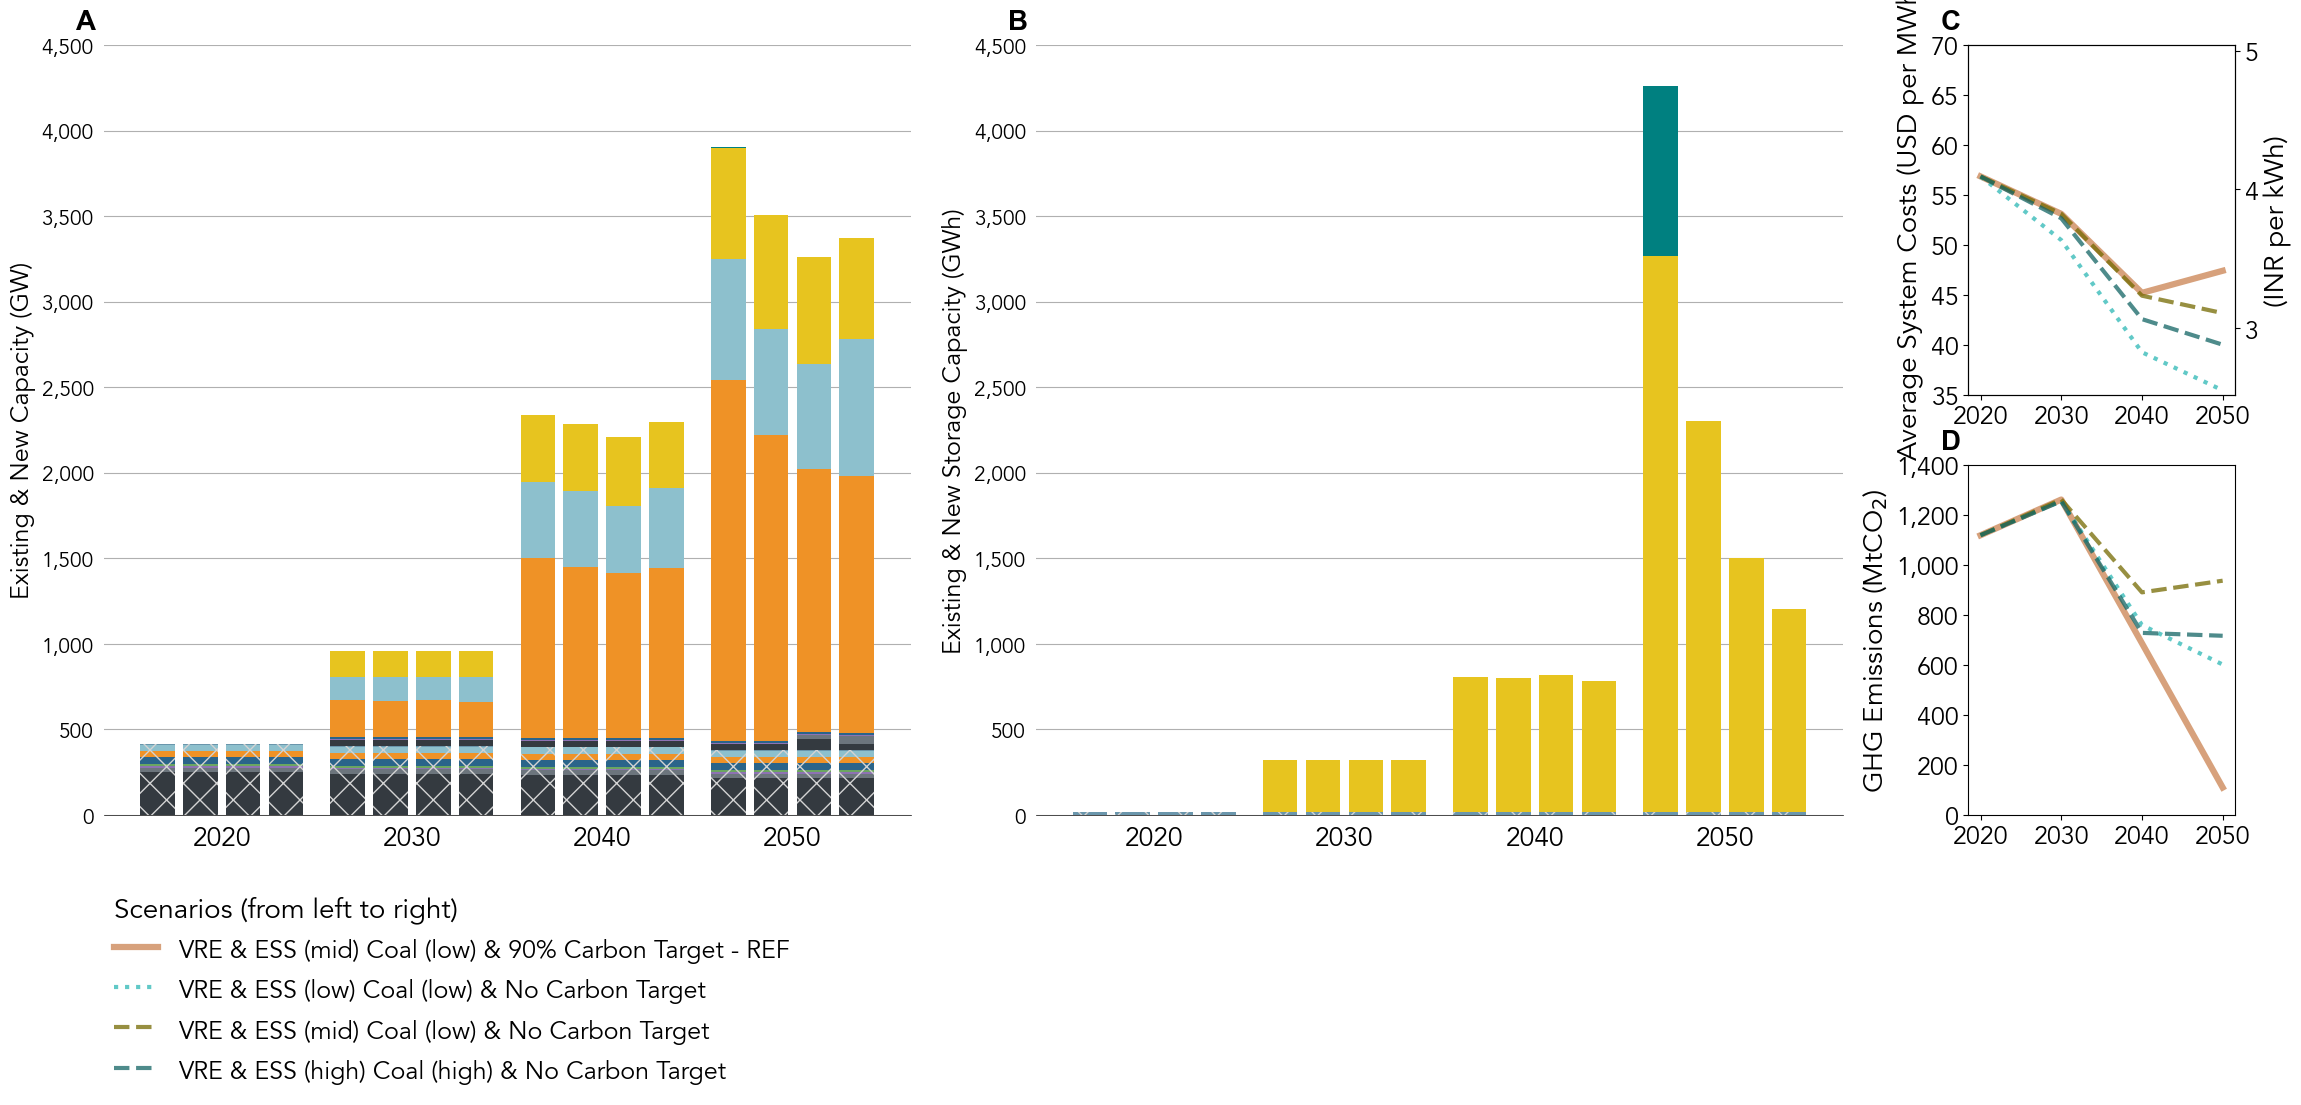

In [4]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel = 'Existing & New Capacity (GW)',
                                legend = False,
                                y_lim_max = 4500,
                                y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel = 'Existing & New Storage Capacity (GWh)', 
                               legend = False,
                               y_lim_max = 4500,
                               y_grid_inc = 500)

df_2_['scen_labels']['marker'] = None

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.8),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_1-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_1-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [5]:
scen_group = 'additional_2'

df_1_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = ld._load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = ld._load_dispatch(df_1_['scen_labels'])

df_1_['capacity'] = prc._group_capacity_by_technology(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = prc._group_dispatch_by_technology(df_1_['dispatch'], tech_labels_)

# Save processed results in CSV files
prc._save_technology_capacity_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_capacity.csv')

prc._save_technology_capacity_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_dispatch.csv')

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(df_2_['scen_labels'])
cost_, demand_ = ld._load_cost(df_2_['scen_labels'])
clean_ = ld._load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = prc._group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = prc._group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9


prc._save_summary_csv(df_2_, path_to_output, file_name = f'{scen_group}' + '-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP2050_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP2050_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP2050_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP2050_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/G

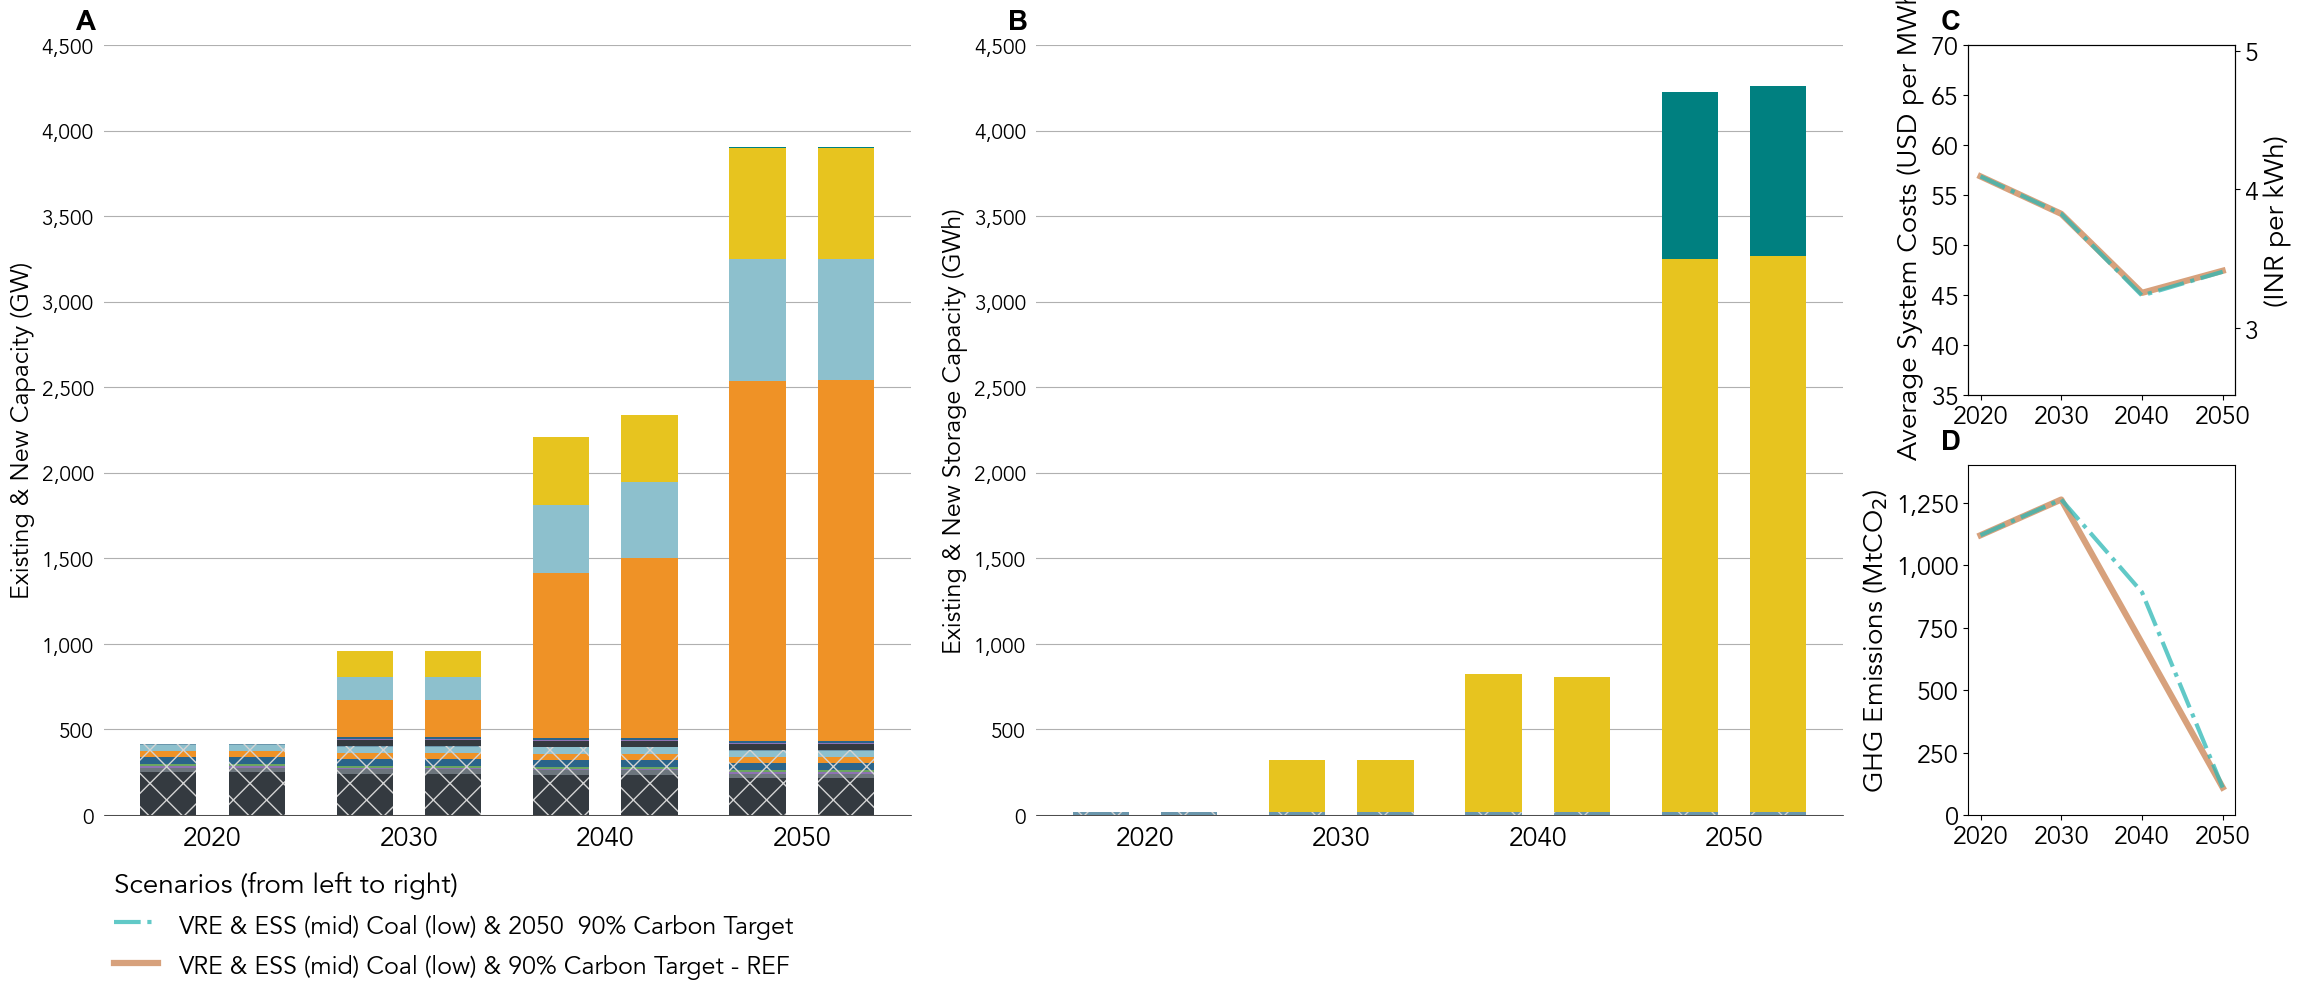

In [6]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')
    
viz._plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 4500,
                                    y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 4500,
                                   y_grid_inc = 500)

df_2_['scen_labels']['marker'] = None

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.5),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_2-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_2-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [7]:
scen_group = 'additional_3'

df_1_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = ld._load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = ld._load_dispatch(df_1_['scen_labels'])

df_1_['capacity'] = prc._group_capacity_by_technology(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = prc._group_dispatch_by_technology(df_1_['dispatch'], tech_labels_)

# Save processed results in CSV files
prc._save_technology_capacity_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_capacity.csv')

prc._save_technology_capacity_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_dispatch.csv')

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(df_2_['scen_labels'])
cost_, demand_ = ld._load_cost(df_2_['scen_labels'])
clean_ = ld._load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = prc._group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = prc._group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(df_2_, path_to_output, file_name = f'{scen_group}' + '-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/grid

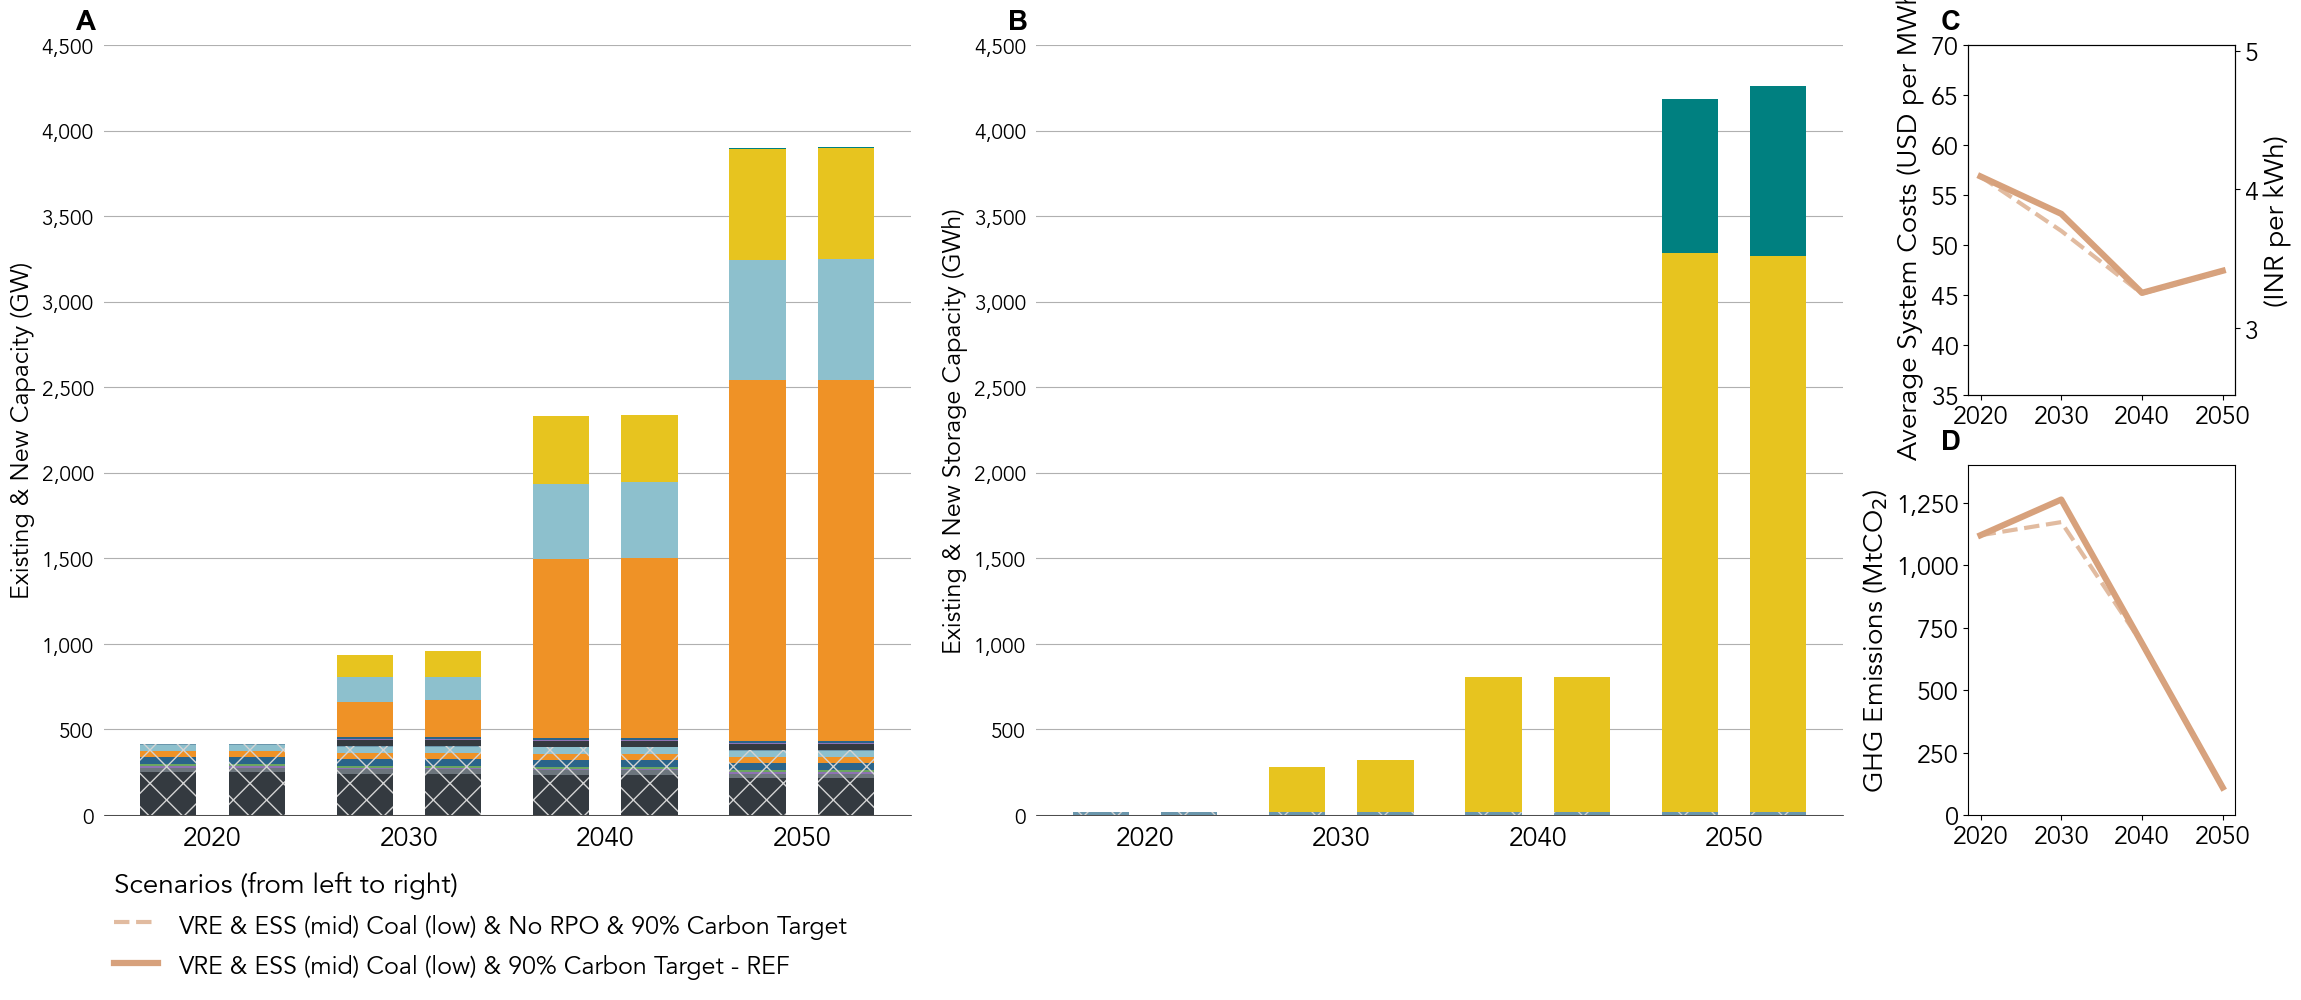

In [8]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 4500,
                                    y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 4500,
                                   y_grid_inc = 500)

df_2_['scen_labels']['marker'] = None

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.5),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_3-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_3-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [10]:
scen_group = 'additional_4'

df_1_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = ld._load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = ld._load_dispatch(df_1_['scen_labels'])

df_1_['capacity'] = prc._group_capacity_by_technology(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = prc._group_dispatch_by_technology(df_1_['dispatch'], tech_labels_)

# Save processed results in CSV files
prc._save_technology_capacity_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_capacity.csv')

prc._save_technology_capacity_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_dispatch.csv')

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(df_2_['scen_labels'])
cost_, demand_ = ld._load_cost(df_2_['scen_labels'])
clean_ = ld._load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = prc._group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = prc._group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(df_2_, path_to_output, file_name = f'{scen_group}' + '-{}.csv')

VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-ind

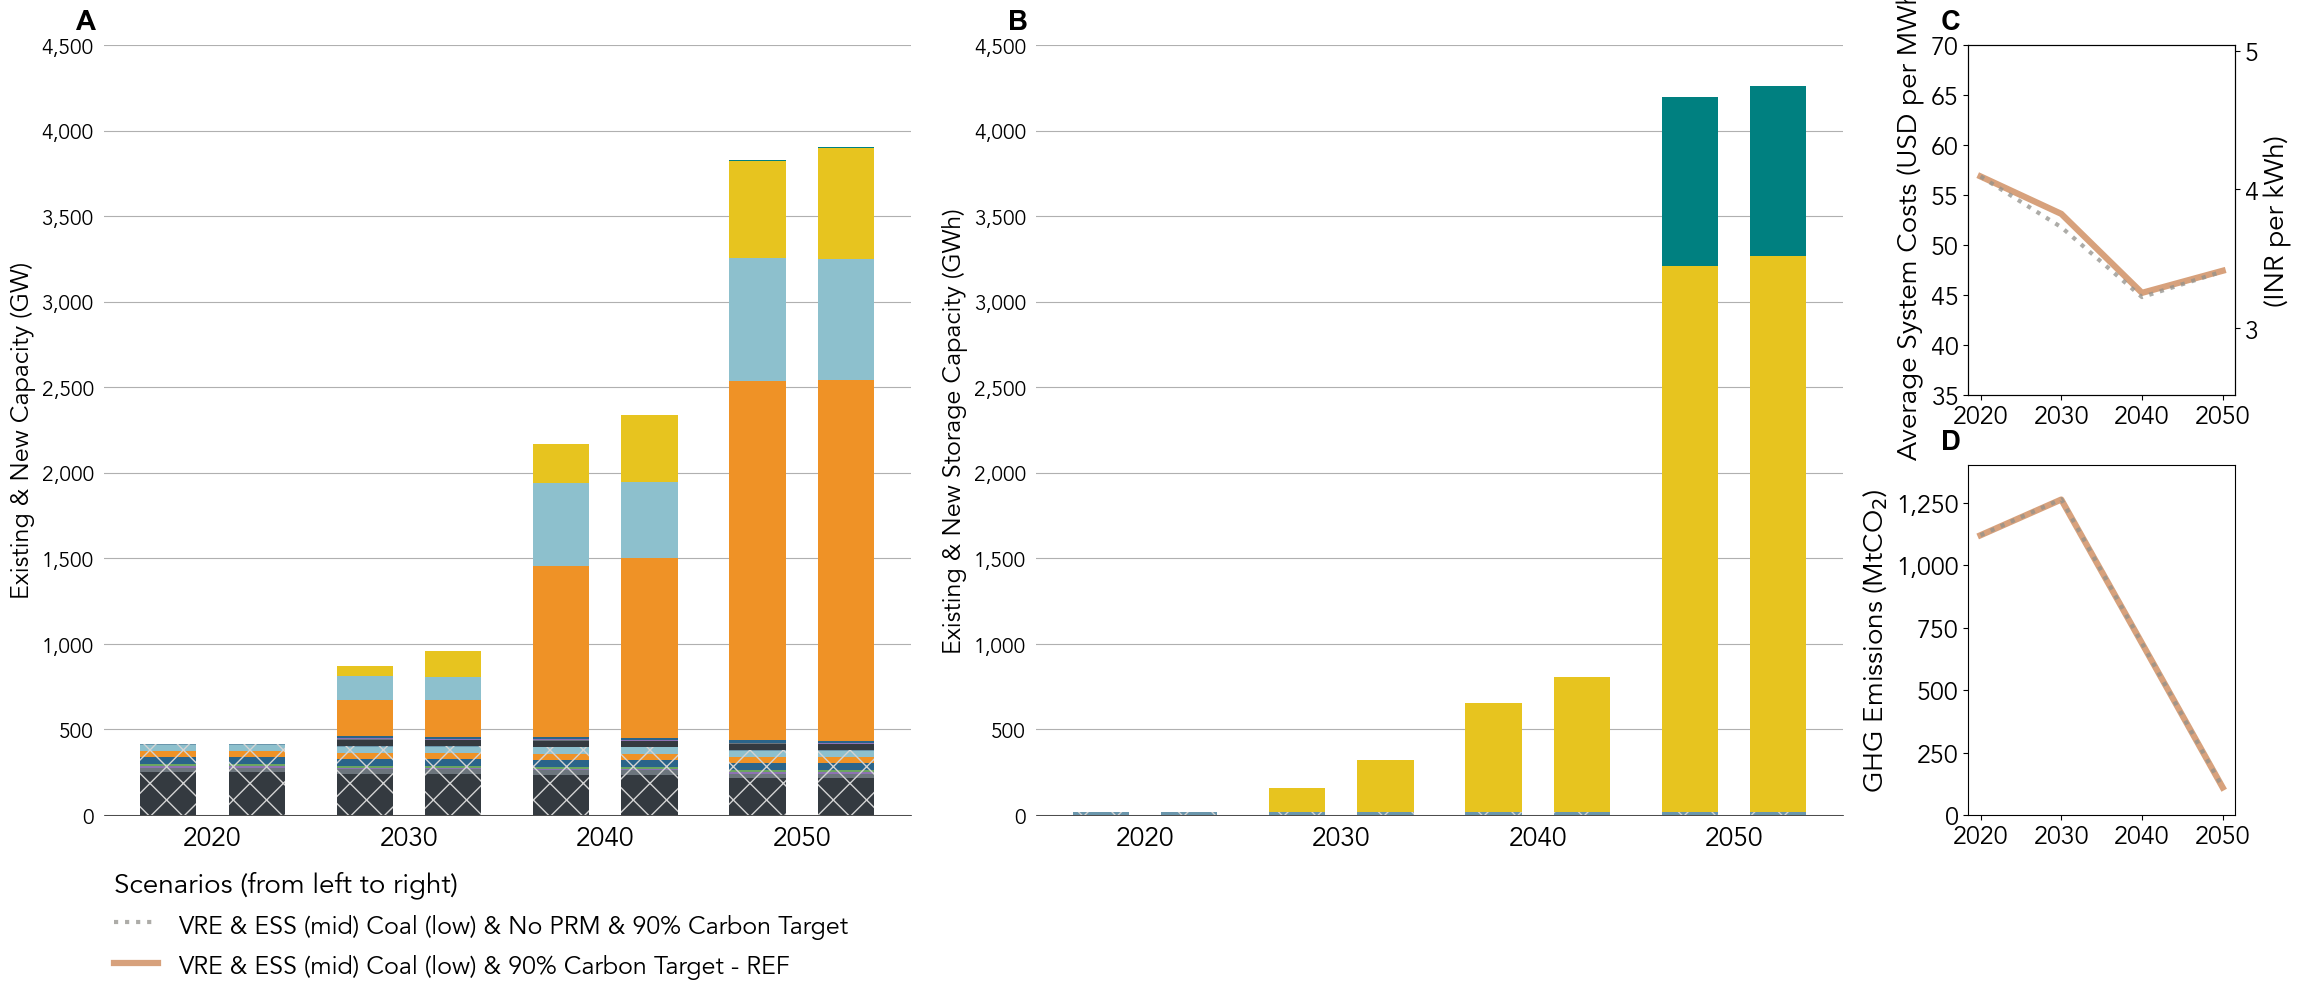

In [11]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 4500,
                                    y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 4500,
                                   y_grid_inc = 500)

df_2_['scen_labels']['marker'] = None

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.5),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_4-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_4-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 300)

plt.show()

In [12]:
scen_group = 'additional_5'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = ld._load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = ld._load_dispatch(df_1_['scen_labels'])

df_1_['capacity'] = prc._group_capacity_by_technology(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = prc._group_dispatch_by_technology(df_1_['dispatch'], tech_labels_)

# Save processed results in CSV files
prc._save_technology_capacity_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_capacity.csv')

prc._save_technology_capacity_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_dispatch.csv')

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(df_2_['scen_labels'])
cost_, demand_ = ld._load_cost(df_2_['scen_labels'])
clean_ = ld._load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = prc._group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = prc._group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(df_2_, path_to_output, file_name = f'{scen_group}' + '-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_NoNewGas_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipeline_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipepile_NoNewCoal_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_NoNewGas_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipeline_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gr

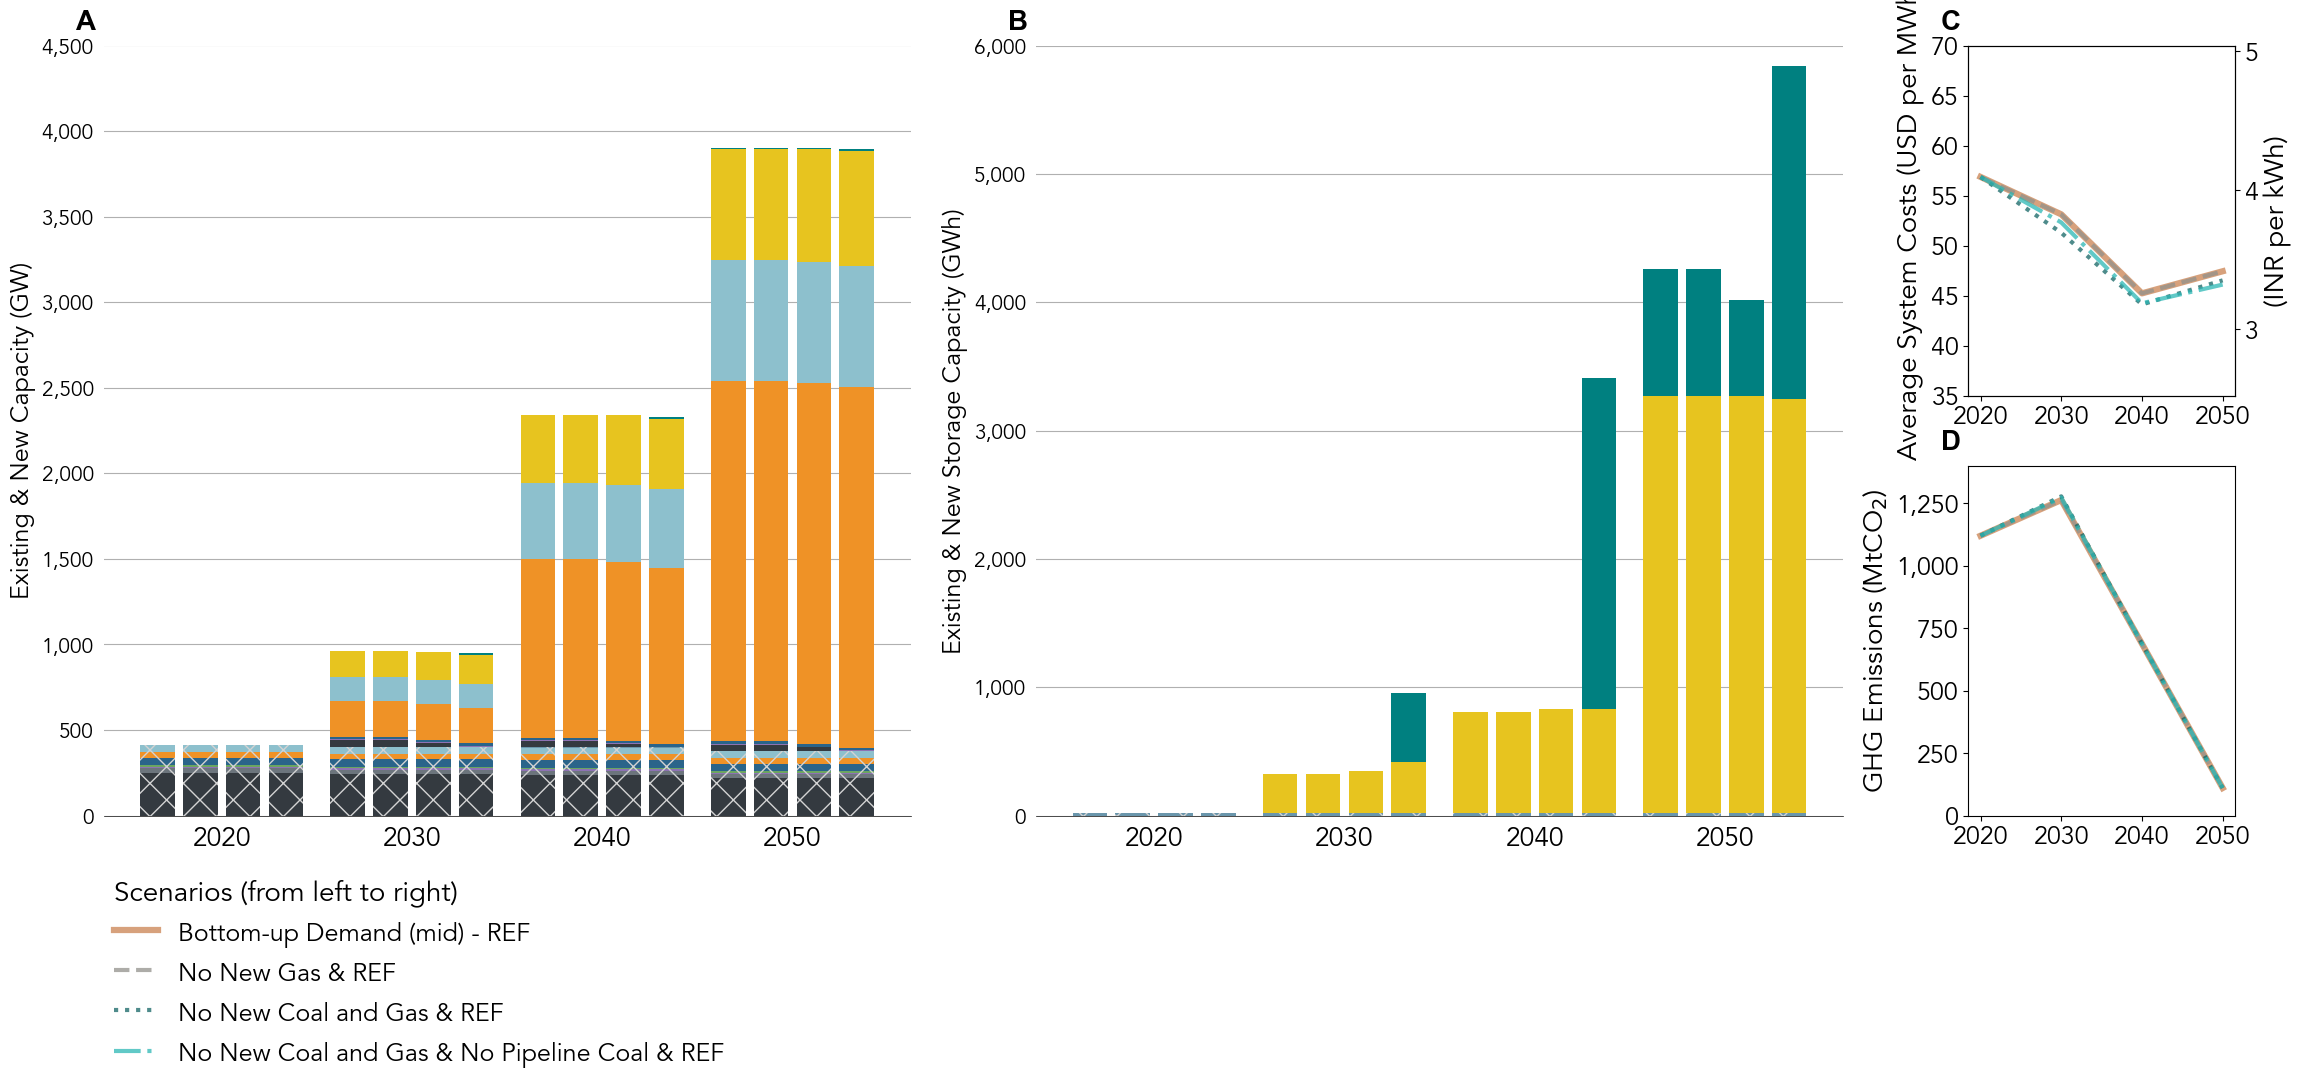

In [13]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 4500,
                                    y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 6000,
                                   y_grid_inc = 1000)

df_2_['scen_labels']['marker'] = None

# Plot the levelized cost of electricity for different scenarios
viz._plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.75),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_5-capacity_summary.pdf',
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_5-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [14]:
scen_group = 'additional_6'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = ld._load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = ld._load_dispatch(df_1_['scen_labels'])

df_1_['capacity'] = prc._group_capacity_by_technology(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = prc._group_dispatch_by_technology(df_1_['dispatch'], tech_labels_)

# Save processed results in CSV files
prc._save_technology_capacity_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_capacity.csv')

prc._save_technology_capacity_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = f'{scen_group}-grouped_dispatch.csv')

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(df_2_['scen_labels'])
cost_, demand_ = ld._load_cost(df_2_['scen_labels'])
clean_ = ld._load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = prc._group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = prc._group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy'] = prc._group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

prc._save_summary_csv(df_2_, path_to_output, file_name = f'{scen_group}' + '-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_NoNewGas_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipeline_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipepile_NoNewCoal_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_NoNewGas_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipeline_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid all /Users/Guille/Desktop/india_power/scenario

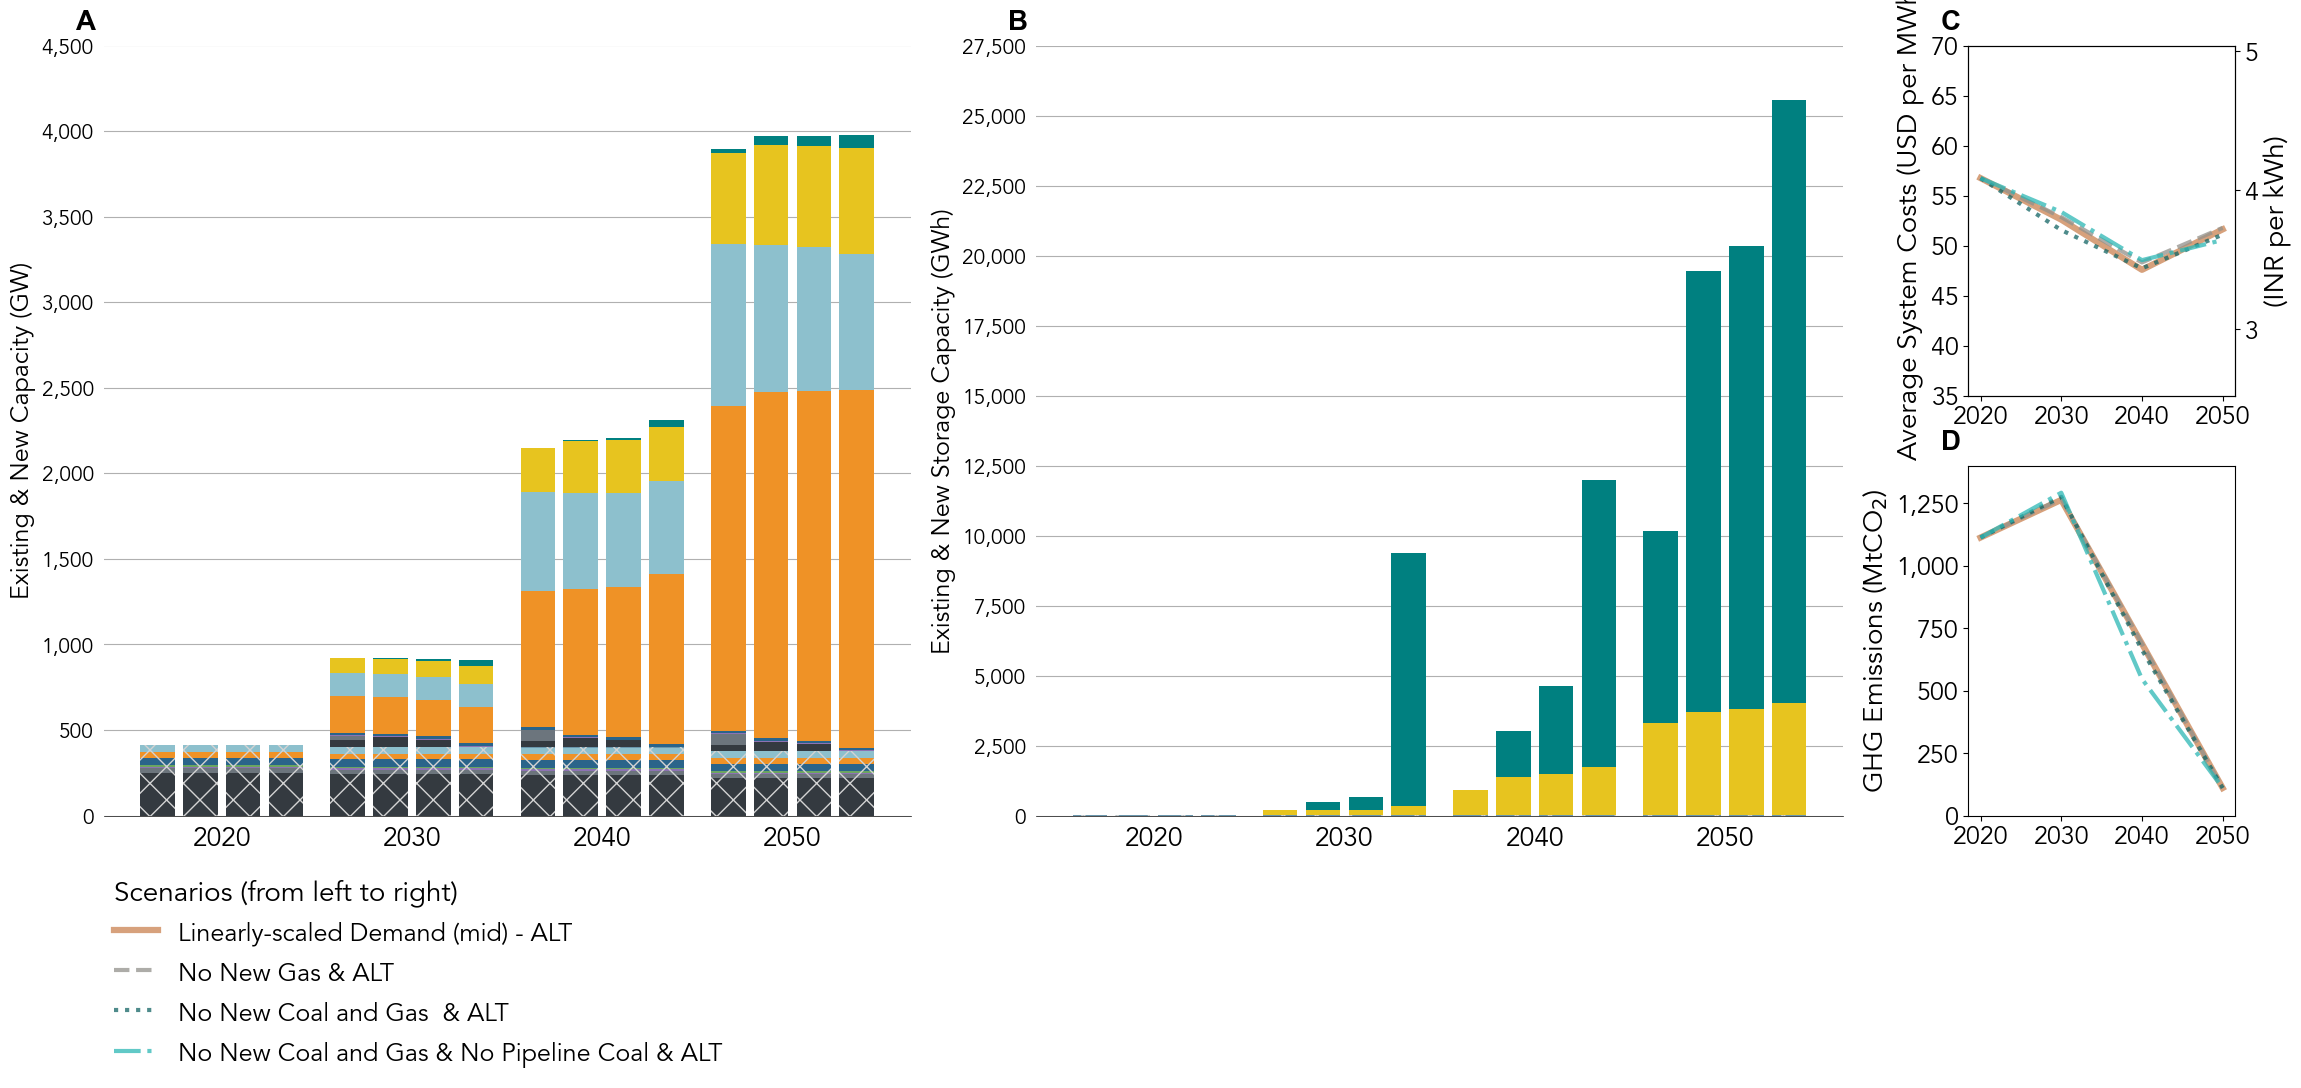

In [15]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 4500,
                                    y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 26000,
                                   y_grid_inc = 2500)

df_2_['scen_labels']['marker'] = None

# Plot the average cost of electricity for different scenarios
viz._plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                       y_min = 35,
                       y_max = 70,
                       legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.75),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_6-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_6-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

# Resource Adequacy

In [15]:
scen_group = 'ra_1'

df_1_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = ld._load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = ld._load_dispatch(df_1_['scen_labels'])

df_1_['capacity'] = prc._group_capacity_by_technology(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = prc._group_dispatch_by_technology(df_1_['dispatch'], tech_labels_)

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(df_2_['scen_labels'])
cost_, demand_ = ld._load_cost(df_2_['scen_labels'])

df_2_['emissions'] = prc._group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = prc._group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india-ra/abhi


KeyError: "['energy_capacity_mwh'] not in index"

In [ ]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 2500,
                                    y_grid_inc = 250)

viz._plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max  = 1000,
                                   y_grid_inc = 125)

df_2_['scen_labels']['marker'] = None

# Plot the levelized cost of electricity for different scenarios
viz._plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                         y_min = 40,
                         y_max = 60,
                         legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.5),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/RA-NoCAP-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/RA-NoCAP-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [ ]:
scen_group = 'ra_2'

df_1_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = ld._load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = ld._load_dispatch(df_1_['scen_labels'])

df_1_['capacity'] = prc._group_capacity_by_technology(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = prc._group_dispatch_by_technology(df_1_['dispatch'], tech_labels_)

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

emission_ = ld._load_carbon_emissions(df_2_['scen_labels'])
clean_ = ld._load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = prc._group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = prc._group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

In [ ]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 2500,
                                    y_grid_inc = 250)

viz._plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 1000,
                                   y_grid_inc = 125)

df_2_['scen_labels']['marker'] = None

# Plot the levelized cost of electricity for different scenarios
viz._plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                         y_min = 40,
                         y_max = 60,
                         legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc = (-7., -0.75),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/RA-90CAP-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/RA-90CAP-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [16]:
scen_csv_file = 'ra_3-scenario_labels.csv'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

df_1_['capacity'] = ld._load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = ld._load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = prc._group_capacity_by_technology(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = prc._group_dispatch_by_technology(df_1_['dispatch'], tech_labels_)

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

emission_ = ld._load_carbon_emissions(df_2_['scen_labels'])
cost_, demand_ = ld._load_cost(df_2_['scen_labels'])

df_2_['emissions'] = prc._group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = prc._group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_4PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_4PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scena

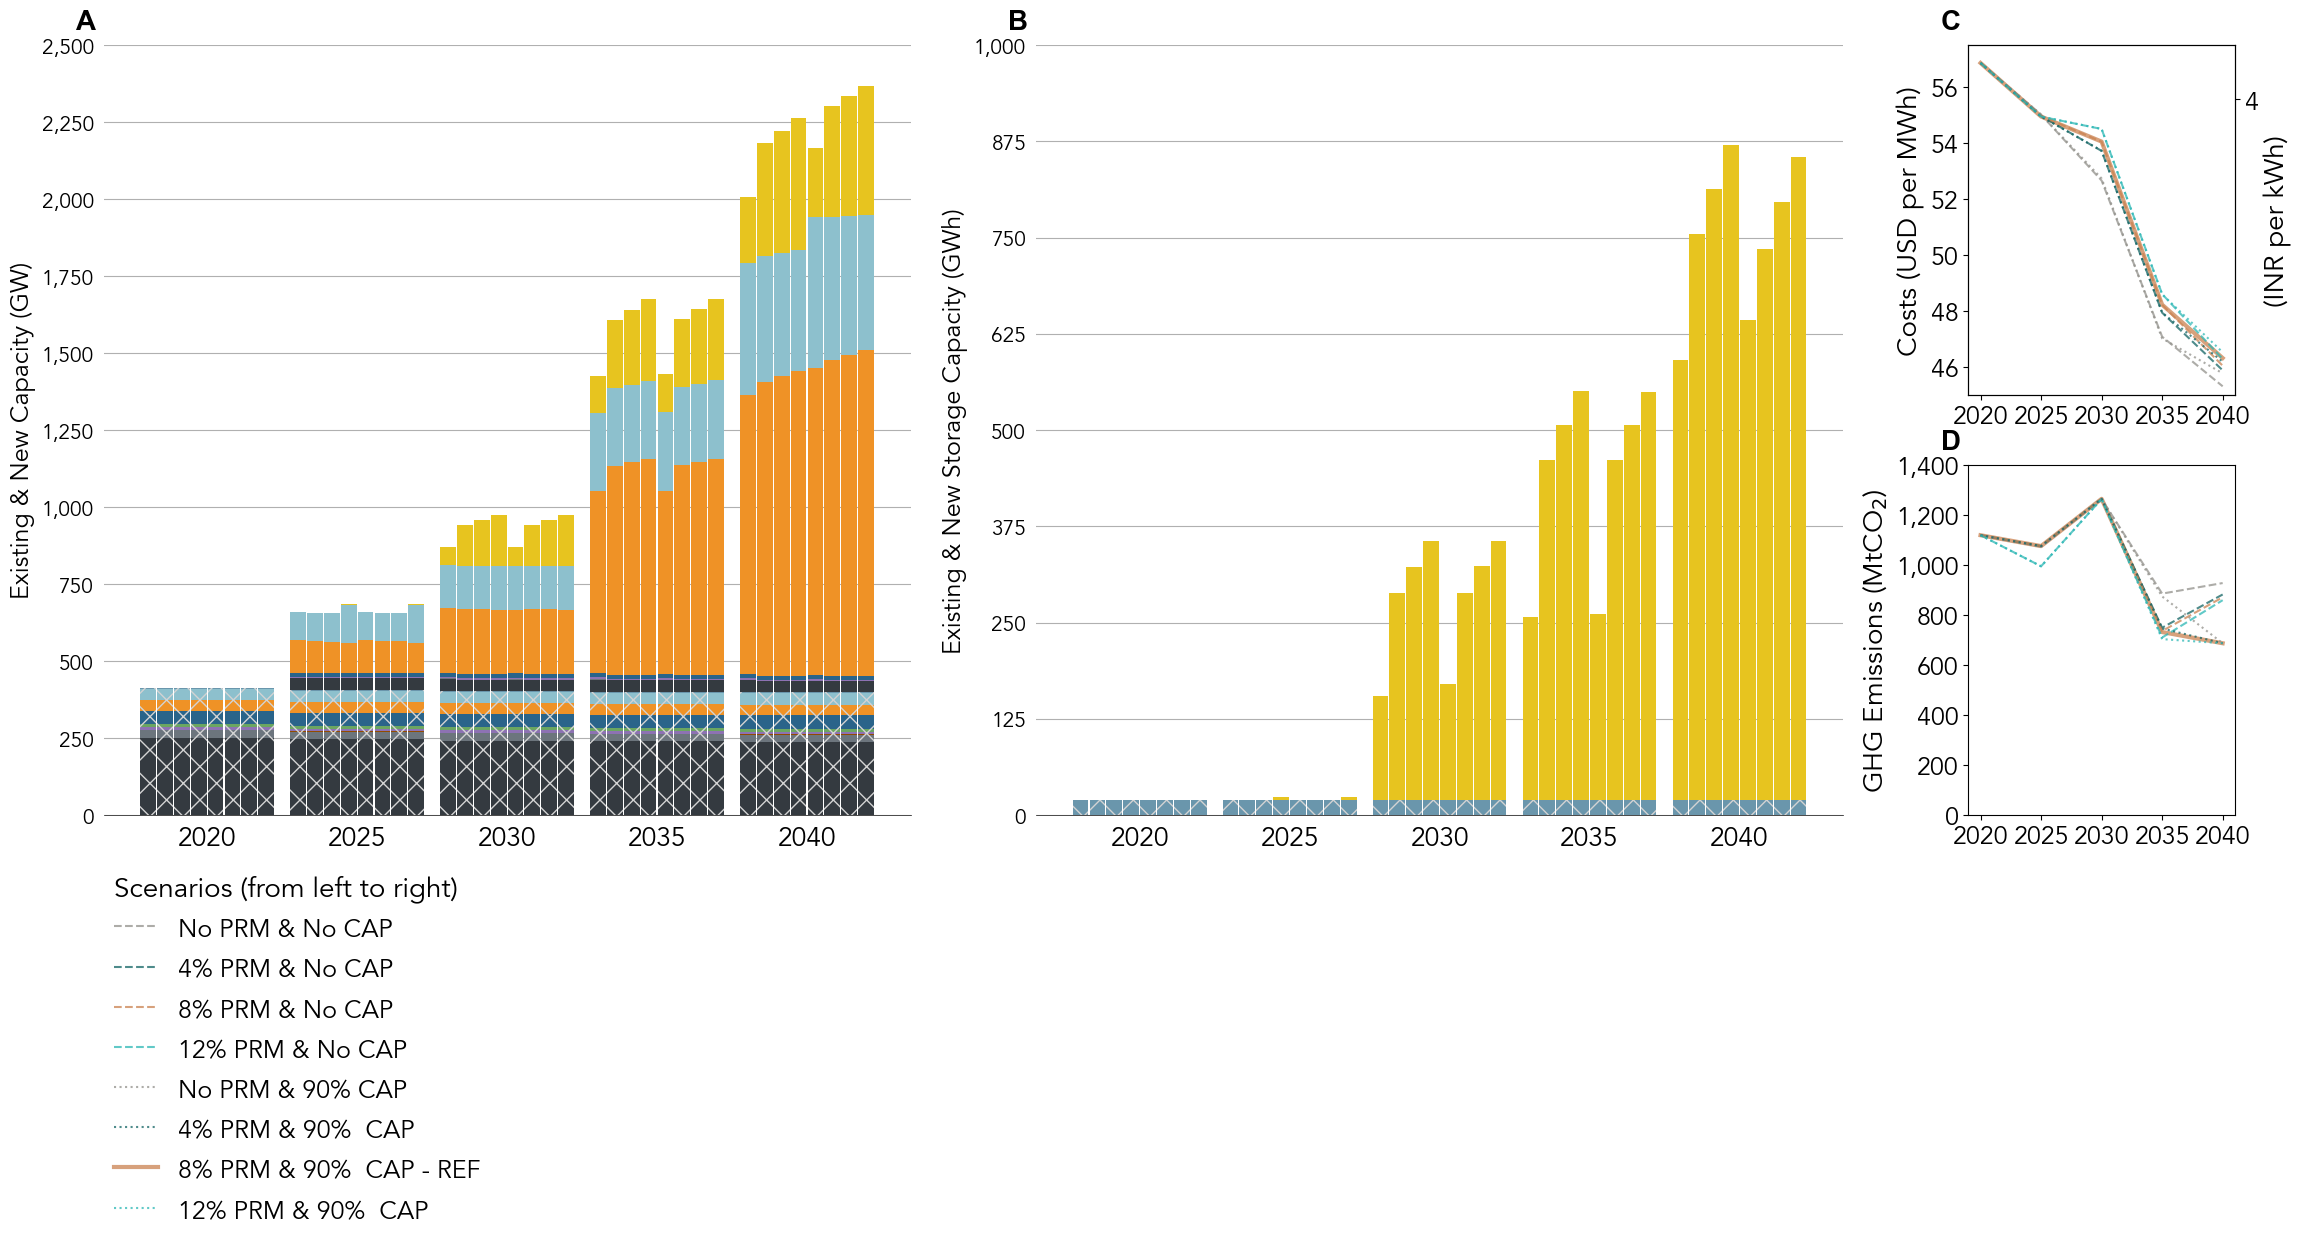

In [22]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 2500,
                                    y_grid_inc = 250)

viz._plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 1000,
                                   y_grid_inc = 125)

df_2_['scen_labels']['marker'] = None

# Plot the levelized cost of electricity for different scenarios
viz._plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                         y_min = 45,
                         y_max = 57.5,
                         legend = False)

# Plot GHG emissions for different scenarios
viz._plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                           y_min = 0,
                           y_max = 1400,
                           legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -1.2),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/RA-No90CAP-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/RA-No90CAP-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()